# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())
print("\nProporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())
print("\nProporción de valores nulos:")
print(usage.isna().mean())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
**Respuesta**
- users → `city`: 11.7% de nulos → proporción media, investigaría el origen (¿fallo de registro?) e imputaría con un valor como "Desconocido" o dejaría como nulo si no afecta el análisis por ciudad.
- users → `churn_date`: 88.35% de nulos → proporción muy alta, pero es un nulo lógico (MNAR): significa que el cliente sigue activo (no ha hecho churn), no un dato faltante por error → lo dejaría como nulo o crearía una bandera `is_active`.
- usage → `date`: 0.125% de nulos → proporción mínima, se puede investigar esos pocos casos puntuales e imputar o eliminar sin impacto en el análisis.
- usage → `duration`: 55.19% de nulos → coincide con los registros de tipo "message" (un mensaje no tiene duración de llamada) → es un nulo lógico (MNAR), lo dejaría como nulo o en 0 según la regla de negocio.
- usage → `length`: 44.74% de nulos → coincide con los registros de tipo "call" (una llamada no tiene longitud de mensaje) → mismo caso, nulo lógico (MNAR), no un error.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...
 **Respuesta**
- La columna user_id (en users): rango de 10000 a 13999, sin valores negativos ni fuera de lógica — se ve limpia.
- La columna age: el mínimo es -999, un valor claramente imposible para una edad → es un sentinel. El resto de la distribución (25%=32, mediana=47, 75%=63, máx=79) es razonable para clientes reales.

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...
 **Respuesta**
- Las columnas id y user_id (en usage): id va de 1 a 40000 (consistente con las 40000 filas), y user_id va de 10000 a 13999, coincidiendo con el rango de users → buena señal para el merge() posterior.
- Las columnas duration y length: ambas tienen mínimo en 0 (llamadas o mensajes de duración/longitud cero, plausible) y máximos altos (120 min, 1490 caracteres) que valdría la pena revisar como posibles outliers más adelante, pero no son sentinels evidentes.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"Valores únicos de '{col}':")
    print(users[col].unique())
    print(f"\nConteo de valores de '{col}':")
    print(users[col].value_counts())
    print("\n" + "-"*40 + "\n")

Valores únicos de 'city':
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Conteo de valores de 'city':
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

----------------------------------------

Valores únicos de 'plan':
['Basico' 'Premium']

Conteo de valores de 'plan':
Basico     2595
Premium    1405
Name: plan, dtype: int64

----------------------------------------



- La columna `city` ...
- La columna `plan` ...
**Respuesta**
- La columna city: tiene un valor '?' (96 registros) que es un sentinel claro — alguien puso "?" en vez de dejar el campo vacío o poner la ciudad real. Además, ya sabíamos que tiene 469 nulos (NaN) por el análisis anterior.
- La columna plan: solo tiene dos categorías válidas, Basico y Premium — sin problemas.


In [16]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` ...
  **Respuesta**
- La columna type: solo tiene text y call — sin valores inesperados.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
**Respuesta**
- users → `age`: valor sentinel de -999 (edad imposible) → acción: reemplazar por NaN y evaluar imputación (ej. mediana) o exclusión de esas filas del análisis de edad.
- users → `city`: valor sentinel '?' (96 casos) → acción: reemplazar '?' por NaN, y tratarlo junto con los NaN ya existentes (11.7% + estos casos) — considerar imputar como "Desconocido" o dejar como nulo si la ciudad no es crítica para el análisis.
- usage → `duration` y `length`: no se detectaron sentinels, pero los máximos (120 min, 1490 caracteres) se revisarán como posibles outliers en el paso de detección estadística (IQR/boxplot).
- users → `plan`, usage → `type`: sin valores inválidos, categorías limpias.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') 

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
**Respuesta**
- Bullet de reg_date:

En reg_date, la mayoría de los registros son de 2022, 2023 y 2024 (conteos similares, ~1300 cada uno), lo cual es coherente con la operación normal de la empresa. Sin embargo, aparecen 40 registros con año 2026, lo cual es imposible ya que los datos solo llegan hasta 2024 — es una fecha futura, probablemente un error de captura (dígito mal escrito, ej. 2026 en vez de 2023, o un error de sistema).

Bullet de date (usage):

En date, el 100% de los registros válidos corresponden al año 2024 (39,950 de 40,000 filas), consistente con el alcance del dataset. Los 50 registros faltantes coinciden con los nulos detectados anteriormente (ahora convertidos a NaT tras el pd.to_datetime). No se encontraron años futuros ni negativos en esta columna.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
**Respuesta**
- reg_date (users): se detectaron 40 registros con año 2026, una fecha futura imposible dado que los datos solo cubren hasta 2024 → acción: tratar estos 40 casos como NaT (fecha inválida) y evaluar si se investigan individualmente o se excluyen del análisis temporal de antigüedad de clientes.
- date (usage): sin fechas fuera de rango, todos los valores válidos corresponden a 2024 → acción: ninguna, la columna está lista para el análisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [21]:
# Reemplazar -999 por la mediana de age

# Calculamos la mediana ya sin el sentinel
age_mediana = users['age'].median()

# Rellenamos los NaN (incluyendo el que era -999) con la mediana
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [23]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, pd.NaT)

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
**Diagnóstico de nulos en duration y length**

Se confirma que los nulos en `duration` y `length` son MAR (Missing At Random), dependientes de la columna `type`:

- Cuando type == 'call': duration está presente en el 100% de los casos; length es nulo en el 99.93% de los casos.
- Cuando type == 'text': length está presente en el 100% de los casos; duration es nulo en el 99.93% de los casos.

El patrón es casi perfecto (>99.9%), confirmando que la ausencia de datos responde a la lógica del negocio (una llamada no tiene longitud de mensaje, y viceversa), no a un error aleatorio. El pequeño porcentaje restante (~0.07%) podría revisarse puntualmente, pero no afecta la conclusión general.

Por esta razón, se dejan como nulos (NaN) en lugar de imputarlos con 0 o eliminarlos, ya que un 0 podría confundirse con un valor real (ej. una llamada de 0 minutos de duración).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,33.739750,5.524381,4.478120,23.317054
std,123.232257,2.358416,2.144238,18.168095
min,-999.000000,0.000000,0.000000,0.000000
25%,32.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

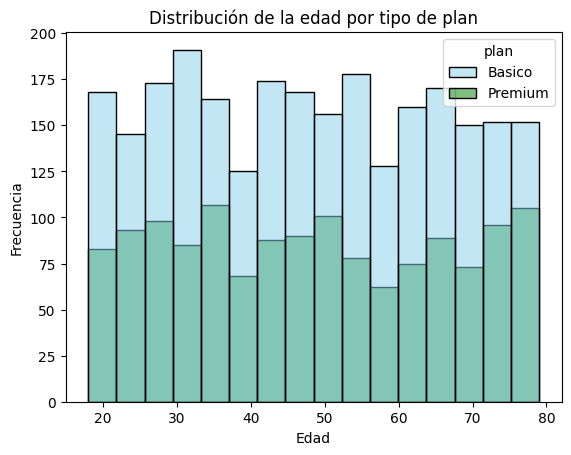

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile[user_profile["age"] != -999], x="age", hue="plan", palette=['skyblue', 'green'])
plt.title("Distribución de la edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución de edad de los usuarios es prácticamente uniforme (o al menos no muestra un sesgo marcado), con frecuencias relativamente parejas en todo el rango de 18 a 79 años, sin una concentración clara en algún grupo etario. Esto sugiere que el servicio no está dirigido a un segmento de edad particular. En cuanto al tipo de plan, la proporción entre Básico y Premium se mantiene bastante constante a lo largo de todos los rangos de edad — no se observa que los usuarios más jóvenes o mayores prefieran claramente un plan sobre el otro, lo cual es consistente con la distribución global (~65% Básico / ~35% Premium) que calculaste antes.

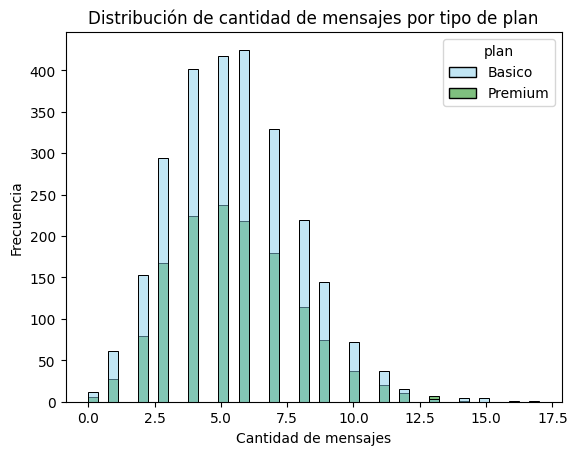

In [34]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=['skyblue', 'green'])
plt.title("Distribución de cantidad de mensajes por tipo de plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución está claramente sesgada a la derecha (right-skewed): la mayoría de los usuarios envía entre 3 y 7 mensajes, con un pico alrededor de 5-6, y luego una cola larga hacia la derecha con muy pocos usuarios que envían 10, 15 o más mensajes. En cuanto al plan, la proporción entre Básico y Premium se mantiene bastante estable a lo largo de toda la distribución — no se observa que los usuarios Premium envíen sistemáticamente más o menos mensajes que los Básico, lo cual sugiere que el volumen de mensajes no está fuertemente asociado al tipo de plan contratado.

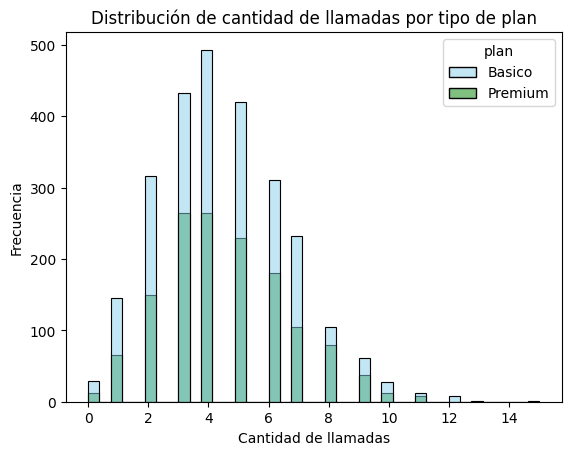

In [35]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=['skyblue', 'green'])
plt.title("Distribución de cantidad de llamadas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución también está sesgada a la derecha, con la mayoría de los usuarios realizando entre 3 y 5 llamadas, un pico claro alrededor de 4, y una cola descendente hacia valores más altos (pocos usuarios superan las 10 llamadas). Al igual que con los mensajes, la proporción entre Básico y Premium se mantiene consistente a lo largo de toda la distribución, sin que un plan concentre notoriamente más o menos llamadas que el otro — lo que refuerza la idea de que el comportamiento de uso (mensajes y llamadas) no varía mucho según el tipo de plan contratado.

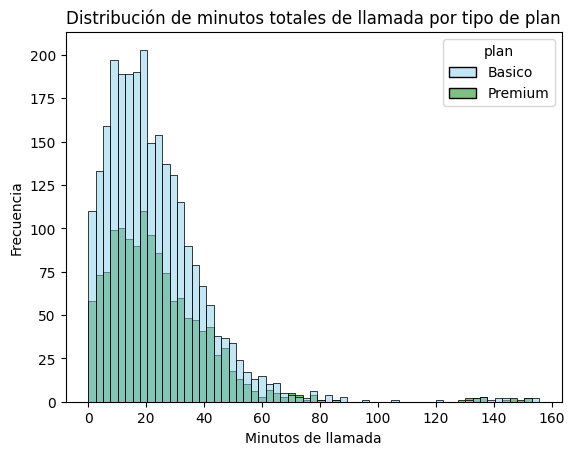

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=['skyblue', 'green'])
plt.title("Distribución de minutos totales de llamada por tipo de plan")
plt.xlabel("Minutos de llamada")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Esta distribución es la más fuertemente sesgada a la derecha de las cuatro variables analizadas. La mayoría de los usuarios acumula entre 10 y 30 minutos totales de llamada, con un pico marcado alrededor de 15-20 minutos, pero tiene una cola larga y visible que se extiende hasta 140-160 minutos, con un pequeño grupo de usuarios "heavy users" que llama muchísimo más que el promedio. Como con las otras variables de uso, la proporción entre Básico y Premium se mantiene similar a lo largo de toda la distribución, sin diferencias marcadas entre planes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

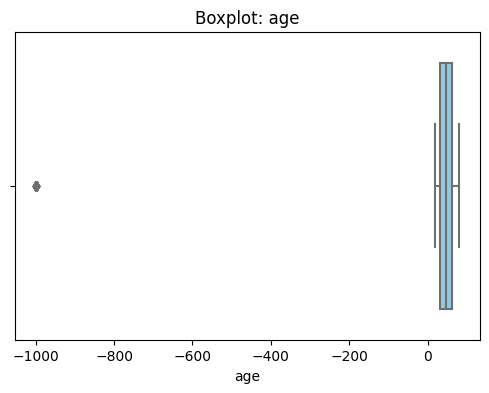

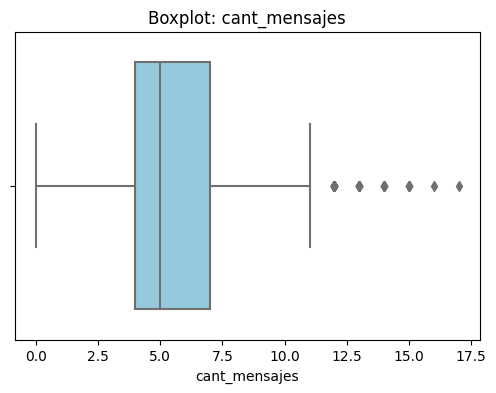

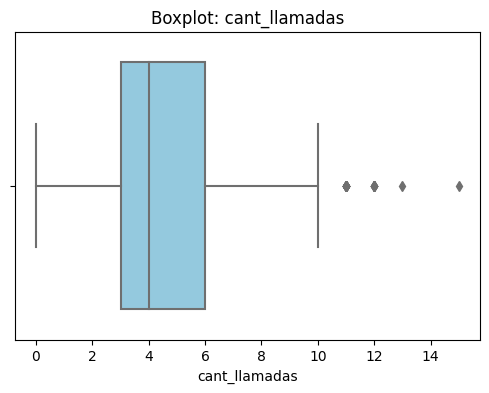

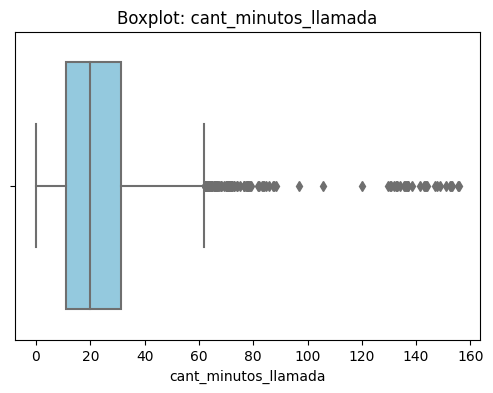

In [37]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: Presenta un outlier extremo y aislado en -1000 aproximadamente (el valor sentinela -999). No es un outlier estadístico real sino un error de dato/valor faltante codificado, y su magnitud es tan extrema que distorsiona por completo la escala del gráfico. El resto de la caja (edades reales) queda comprimido en un rango muy angosto cerca de 0, lo cual confirma que hay que tratar este valor por separado antes de seguir analizando age
- cant_mensajes: Presenta varios outliers hacia la derecha (valores entre 12 y 17), formando una fila clara de puntos más allá del bigote superior (~11). Son pocos y discretos, consistentes con usuarios que simplemente envían más mensajes de lo habitual.
- cant_llamadas: presenta un patrón similar — outliers hacia la derecha, entre 11 y 15 llamadas, más allá del bigote superior (~10). También son relativamente pocos.
- cant_minutos_llamada: Es la variable con más outliers y los más extremos, con un grupo numeroso de puntos entre 60 y 160 minutos, más allá del bigote superior (~60). A diferencia de las otras dos, aquí los outliers son mucho más numerosos y se extienden en un rango amplio, lo que sugiere una cola derecha bastante "pesada" — hay un grupo no despreciable de usuarios con consumo de llamadas mucho mayor al típico.

In [38]:
# Calcular límites con el método IQR
columnas_limites = []

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f"{col}: límite inferior = {limite_inferior:.2f}, límite superior = {limite_superior:.2f}")
    
    # Crear columna booleana marcando si el valor es outlier
    nombre_col_outlier = f"{col}_outlier"
    user_profile[nombre_col_outlier] = (user_profile[col] < limite_inferior) | (user_profile[col] > limite_superior)
    columnas_limites.append(nombre_col_outlier)

age: límite inferior = -14.50, límite superior = 109.50
cant_mensajes: límite inferior = -0.50, límite superior = 11.50
cant_llamadas: límite inferior = -1.50, límite superior = 10.50
cant_minutos_llamada: límite inferior = -19.32, límite superior = 61.86


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age_outlier,cant_mensajes_outlier,cant_llamadas_outlier,cant_minutos_llamada_outlier
count,4000,4000,4000,4000
unique,2,2,2,2
top,False,False,False,False
freq,3945,3954,3970,3891


💡Insights: 
- cant_mensajes: 46 registros (1.15%) superan el límite superior de 11.5 mensajes. Son valores plausibles (12 a 17 mensajes no es un error, solo usuarios más activos). Decisión: mantenerlos — representan variación natural de comportamiento, y eliminarlos perdería información real sobre usuarios de alto uso.
- cant_llamadas: mantener o no outliers, porqué? 30 registros (0.75%) superan el límite superior de 10.5 llamadas. Mismo criterio: son pocos y plausibles. Decisión: mantenerlos, ya que no hay evidencia de que sean errores de captura.
- cant_minutos_llamada: mantener o no outliers, porqué? 109 registros (2.73%) — la proporción más alta de las cuatro — superan el límite superior de 61.86 minutos. Aun siendo el grupo más numeroso, siguen siendo valores de consumo posibles (nada indica error de medición), simplemente reflejan un subgrupo de "heavy users" en minutos de llamada. Decisión: mantenerlos, ya que eliminarlos sesgaría el análisis al ocultar un patrón de uso real y potencialmente relevante para el negocio (ej. identificar usuarios de alto consumo para ofertas o segmentación).

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso
import numpy as np
condiciones = [
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10)
]

resultados = ["Bajo uso", "Uso medio"]

user_profile["grupo_uso"] = np.select(condiciones, resultados, default="Alto uso")

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,age_outlier,cant_mensajes_outlier,cant_llamadas_outlier,cant_minutos_llamada_outlier,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,False,False,False,False,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,False,False,False,False,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,False,False,False,False,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,False,False,False,False,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,False,False,False,False,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [44]:
# Crear columna grupo_edad
condiciones_edad = [
    (user_profile["age"] < 30),
    (user_profile["age"] < 60)
]

resultados_edad = ["Joven", "Adulto"]

user_profile["grupo_edad"] = np.select(condiciones_edad, resultados_edad, default="Adulto Mayor")

In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,age_outlier,cant_mensajes_outlier,cant_llamadas_outlier,cant_minutos_llamada_outlier,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,False,False,False,False,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,False,False,False,False,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,False,False,False,False,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,False,False,False,False,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,False,False,False,False,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

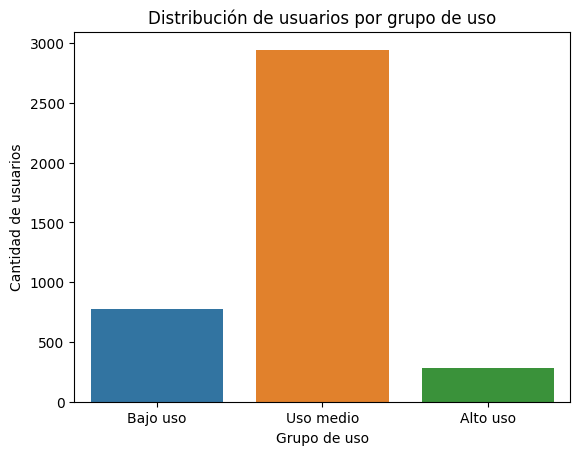

In [46]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso", order=["Bajo uso", "Uso medio", "Alto uso"])
plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

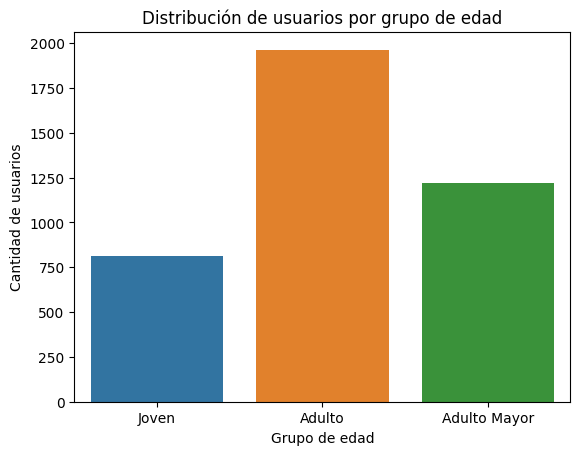

In [47]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad", order=["Joven", "Adulto", "Adulto Mayor"])
plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna age contenía un valor sentinela (-999) en 55 registros (1.38% del total), usado aparentemente para marcar datos faltantes o inválidos. Este valor distorsionaba las estadísticas descriptivas (mínimo de -999 en lugar de un rango real de 18-79 años) y debe tratarse como dato faltante antes de cualquier análisis basado en edad.
- Un usuario (0.025% del total) no tenía ningún registro en la tabla usage, quedando con valores nulos en cant_mensajes, cant_llamadas y cant_minutos_llamada tras el merge — un caso aislado, probablemente un usuario recién registrado sin actividad aún.


🔍 **Segmentos por Edad**
- La base de usuarios se distribuye en tres grupos: Adulto (30-59 años) es el más numeroso con ~49% de los usuarios, seguido de Adulto Mayor (60+) con ~31%, y Joven (<30) con ~20%.
- La distribución de edad en sí es prácticamente uniforme a lo largo de todo el rango (18-79 años), sin concentración marcada en ningún tramo — la diferencia en tamaño de los grupos responde al ancho de cada rango definido, no a un sesgo real de la población.
- El tipo de plan (Básico/Premium) se mantiene proporcional en todos los grupos de edad, sin que un segmento etario prefiera claramente un plan sobre otro.


📊 **Segmentos por Nivel de Uso**
- El 74% de los usuarios se ubica en "Uso medio", un 19.5% en "Bajo uso", y solo un 7% en "Alto uso" — consistente con el sesgo a la derecha observado en cant_mensajes, cant_llamadas y cant_minutos_llamada, donde la mayoría de usuarios se concentra en valores moderados y una minoría concentra un consumo mucho mayor.
- Los outliers detectados en las variables de uso (1.15% en mensajes, 0.75% en llamadas, 2.73% en minutos de llamada) no representan errores de datos, sino usuarios genuinamente más activos — se decidió mantenerlos en el análisis por representar comportamiento real y valioso para el negocio.


➡️ Esto sugiere que ConnectaTel tiene una base de clientes mayoritariamente estable y de consumo moderado, con dos segmentos de interés particular para el negocio: un núcleo grande de usuarios de "Uso medio" que sostiene la operación, y un grupo pequeño pero significativo de "Alto uso" que consume desproporcionadamente más minutos de llamada — el segmento con mayor potencial de ingreso adicional si se le ofrece un producto ajustado a su comportamiento.
💡 Segmentos más valiosos para ConnectaTel

El segmento de "Alto uso" (~7% de los usuarios) es el más valioso en términos de potencial de ingreso: consume significativamente más minutos de llamada y mensajes que el resto, lo que sugiere alta dependencia del servicio y probablemente mayor disposición a pagar por un plan superior.
Dentro de este segmento, sería valioso cruzar con plan para verificar si estos usuarios de alto consumo ya están en Premium o si hay oportunidad de upgrade entre los que aún están en Básico.

💡 **Recomendaciones**
- Corregir el valor sentinela -999 en age antes de cualquier análisis o reporte que dependa de esta variable, reemplazándolo por NaN y evaluando si se puede recuperar el dato real o si debe excluirse de los cálculos de edad.
- Diseñar una oferta o plan diferenciado dirigido al segmento de "Alto uso" (~7% de la base), dado que representa el grupo con mayor consumo de minutos y mensajes — podría incluir tarifas por volumen o beneficios adicionales que incentiven su retención, ya que es el segmento con mayor riesgo de buscar alternativas si sienten que su consumo no está bien cubierto por su plan actual.
- Investigar el patrón de uso "Bajo uso" (~19.5%): entender si estos usuarios están subutilizando el servicio por desconocimiento de funciones, o si genuinamente necesitan menos —  esto podría abrir oportunidades de planes más económicos o de fidelización. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/jocalpe95-lab/connectatel-analysis